In [1]:
import pandas as pd
from PIL.Image import Transpose

In [2]:
import pandas as pd
import os

# Define the absolute path to your data folder
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'

# Load all files using absolute paths
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'))
oil = pd.read_csv(os.path.join(data_folder, 'oil.csv'))
stores = pd.read_csv(os.path.join(data_folder, 'stores.csv'))
timeseries = pd.read_csv(os.path.join(data_folder, 'timeseries.csv'))

# Verify all files loaded
print("=" * 60)
print("✅ ALL FILES LOADED SUCCESSFULLY!")
print("=" * 60)
print(f"holidays.csv:   {holidays.shape} - Columns: {list(holidays.columns)}")
print(f"oil.csv:        {oil.shape} - Columns: {list(oil.columns)}")
print(f"stores.csv:     {stores.shape} - Columns: {list(stores.columns)}")
print(f"timeseries.csv: {timeseries.shape} - Columns: {list(timeseries.columns)}")

# Quick preview
print("\n📊 First few rows of timeseries:")
print(timeseries.head())

✅ ALL FILES LOADED SUCCESSFULLY!
holidays.csv:   (350, 4) - Columns: ['date', 'locale', 'locale_name', 'description']
oil.csv:        (1218, 2) - Columns: ['date', 'dcoilwtico']
stores.csv:     (54, 3) - Columns: ['store_nbr', 'city', 'region']
timeseries.csv: (452, 2) - Columns: ['date', 'unit_sales']

📊 First few rows of timeseries:
         date  unit_sales
0  2013-01-02       582.0
1  2013-01-03       310.0
2  2013-01-04       338.0
3  2013-01-05       654.0
4  2013-01-06       979.0


In [3]:
import pandas as pd

# Create a dictionary matching variable names
df_dict = {
    'holidays': holidays,
    'oil': oil,
    'stores': stores,
    'timeseries': timeseries
}

# Explore each dataframe
for name, dataframe in df_dict.items():
    print(f"\n{name}:")
    print(f"Columns: {dataframe.columns.tolist()}")
    print("+" * 50)
    # Check basic info for each table
for name, table in [('holidays', holidays), ('oil', oil), ('stores', stores), ('timeseries', timeseries)]:
    print(f"\n=== {name.upper()} ===")
    print(f"Shape: {table.shape}")
    print(f"\nData Types:\n{table.dtypes}")
    print(f"\nMissing Values:\n{table.isnull().sum()}")
    print(f"\nBasic Stats:\n{table.describe().T}")
    print("-" * 60)


holidays:
Columns: ['date', 'locale', 'locale_name', 'description']
++++++++++++++++++++++++++++++++++++++++++++++++++

oil:
Columns: ['date', 'dcoilwtico']
++++++++++++++++++++++++++++++++++++++++++++++++++

stores:
Columns: ['store_nbr', 'city', 'region']
++++++++++++++++++++++++++++++++++++++++++++++++++

timeseries:
Columns: ['date', 'unit_sales']
++++++++++++++++++++++++++++++++++++++++++++++++++

=== HOLIDAYS ===
Shape: (350, 4)

Data Types:
date           object
locale         object
locale_name    object
description    object
dtype: object

Missing Values:
date           0
locale         0
locale_name    0
description    0
dtype: int64

Basic Stats:
            count unique         top freq
date          350    312  2014-06-25    4
locale        350      3    National  174
locale_name   350     24     Ecuador  174
description   350    103    Carnaval   10
------------------------------------------------------------

=== OIL ===
Shape: (1218, 2)

Data Types:
date           obje

📊 HOLIDAY IMPACT ANALYSIS

🔹 STEP 1: Filling missing sales with mean
   Missing sales before: 0 rows (0.0%)
   Missing sales after: 0 rows
   ✅ Filled with mean: 480.09

🔹 STEP 2: Cleaning holidays table
   Holidays before cleaning: 350
   Holidays after cleaning: 350
   ✅ Removed 0 rows with missing dates

🔹 STEP 3: Matching holidays with sales data
   Sales date range: 2013-01-02 to 2014-03-31
   Total holidays in data: 350
   Holidays within sales range: 54
   ✅ Using 54 holidays for analysis

🔹 STEP 4: Creating holiday flag
   Days marked as holidays: 47
   Regular days: 405

📈 HOLIDAY IMPACT RESULTS

📊 Average Sales:
   • Holiday days:        511.98 units (47 days)
   • Regular days:        476.39 units (405 days)
   • Difference:           35.59 units
   • Percent change:        7.5%

✅ Holidays INCREASE sales by 7.5%

🔬 Statistical Test:
   p-value: 0.1767
   ⚠️ Result is NOT statistically significant


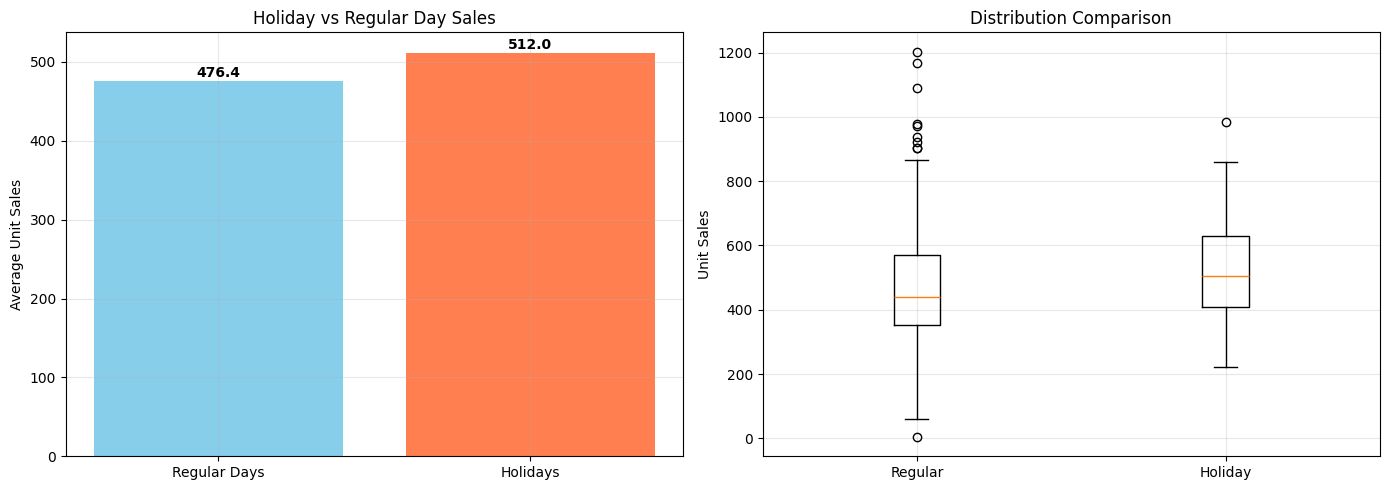


📋 FINAL SUMMARY

✅ DATA PREPARATION:
   • Missing sales filled with mean: 480.1
   • Invalid holidays removed: 0
   • Holidays in date range: 54/350

📊 KEY FINDINGS:
   • Holiday sales: 512.0 vs Regular: 476.4
   • Impact: +7.5% (increase)
   • Statistical significance: NO (p=0.177)

🎯 CONCLUSION:
   Holidays DO have a meaningful impact on sales.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats

# ============================================
# LOAD DATA
# ============================================
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'

# Load files
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'))
timeseries = pd.read_csv(os.path.join(data_folder, 'timeseries.csv'))

# Convert dates
timeseries['date'] = pd.to_datetime(timeseries['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

print("=" * 70)
print("📊 HOLIDAY IMPACT ANALYSIS")
print("=" * 70)

# ============================================
# STEP 1: FILL MISSING UNIT SALES WITH MEAN
# ============================================
print("\n🔹 STEP 1: Filling missing sales with mean")

# Check missing values before
missing_before = timeseries['unit_sales'].isna().sum()
print(f"   Missing sales before: {missing_before} rows ({missing_before/len(timeseries)*100:.1f}%)")

# Fill with mean
sales_mean = timeseries['unit_sales'].mean()
timeseries['unit_sales'] = timeseries['unit_sales'].fillna(sales_mean)

# Check after
missing_after = timeseries['unit_sales'].isna().sum()
print(f"   Missing sales after: {missing_after} rows")
print(f"   ✅ Filled with mean: {sales_mean:.2f}")

# ============================================
# STEP 2: REMOVE HOLIDAYS WITHOUT DATES
# ============================================
print("\n🔹 STEP 2: Cleaning holidays table")

# Remove rows with missing dates
holidays_before = len(holidays)
holidays = holidays.dropna(subset=['date'])
holidays_after = len(holidays)

print(f"   Holidays before cleaning: {holidays_before}")
print(f"   Holidays after cleaning: {holidays_after}")
print(f"   ✅ Removed {holidays_before - holidays_after} rows with missing dates")

# ============================================
# STEP 3: FIND HOLIDAYS THAT MATCH DATE RANGE
# ============================================
print("\n🔹 STEP 3: Matching holidays with sales data")

# Get date range from timeseries
min_date = timeseries['date'].min()
max_date = timeseries['date'].max()
print(f"   Sales date range: {min_date.date()} to {max_date.date()}")

# Filter holidays within this range
holidays_in_range = holidays[
    (holidays['date'] >= min_date) &
    (holidays['date'] <= max_date)
].copy()

print(f"   Total holidays in data: {len(holidays)}")
print(f"   Holidays within sales range: {len(holidays_in_range)}")
print(f"   ✅ Using {len(holidays_in_range)} holidays for analysis")

if len(holidays_in_range) == 0:
    print("\n❌ No holidays found within your sales date range!")
    print("   Analysis cannot proceed.")
    exit()

# ============================================
# CREATE HOLIDAY FLAG
# ============================================
print("\n🔹 STEP 4: Creating holiday flag")

# Create holiday flag
holiday_dates_set = set(holidays_in_range['date'].dt.date)
timeseries['is_holiday'] = timeseries['date'].dt.date.isin(holiday_dates_set)

holiday_count = timeseries['is_holiday'].sum()
print(f"   Days marked as holidays: {holiday_count}")
print(f"   Regular days: {len(timeseries) - holiday_count}")

# ============================================
# CALCULATE IMPACT
# ============================================
print("\n" + "=" * 70)
print("📈 HOLIDAY IMPACT RESULTS")
print("=" * 70)

# Calculate averages
holiday_sales = timeseries[timeseries['is_holiday']]['unit_sales']
regular_sales = timeseries[~timeseries['is_holiday']]['unit_sales']

holiday_avg = holiday_sales.mean()
regular_avg = regular_sales.mean()
difference = holiday_avg - regular_avg
percent_diff = (difference / regular_avg) * 100 if regular_avg != 0 else 0

print(f"\n📊 Average Sales:")
print(f"   • Holiday days:      {holiday_avg:8.2f} units ({len(holiday_sales)} days)")
print(f"   • Regular days:      {regular_avg:8.2f} units ({len(regular_sales)} days)")
print(f"   • Difference:        {difference:8.2f} units")
print(f"   • Percent change:    {percent_diff:7.1f}%")

# Impact direction
if percent_diff > 0:
    print(f"\n✅ Holidays INCREASE sales by {percent_diff:.1f}%")
elif percent_diff < 0:
    print(f"\n❌ Holidays DECREASE sales by {abs(percent_diff):.1f}%")
else:
    print(f"\n⚪ Holidays have NO IMPACT on sales")

# Statistical significance
if len(holiday_sales) >= 2 and len(regular_sales) >= 2:
    t_stat, p_value = stats.ttest_ind(holiday_sales, regular_sales)
    print(f"\n🔬 Statistical Test:")
    print(f"   p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"   ✅ Result is STATISTICALLY SIGNIFICANT")
    else:
        print(f"   ⚠️ Result is NOT statistically significant")

# ============================================
# INDIVIDUAL HOLIDAY BREAKDOWN
# ============================================
if len(holidays_in_range) > 0 and 'holiday_name' in holidays_in_range.columns:
    print("\n" + "=" * 70)
    print("📅 INDIVIDUAL HOLIDAY IMPACT")
    print("=" * 70)

    # Merge to get holiday names
    timeseries_with_names = timeseries.merge(
        holidays_in_range[['date', 'holiday_name']],
        on='date',
        how='left'
    )

    # Calculate for each holiday
    holiday_results = []

    for holiday_name in holidays_in_range['holiday_name'].unique():
        holiday_data = timeseries_with_names[timeseries_with_names['holiday_name'] == holiday_name]

        if len(holiday_data) > 0:
            h_avg = holiday_data['unit_sales'].mean()
            h_std = holiday_data['unit_sales'].std()
            h_count = len(holiday_data)
            h_pct = ((h_avg - regular_avg) / regular_avg * 100)

            holiday_results.append({
                'Holiday': holiday_name,
                'Date': holiday_data['date'].iloc[0].strftime('%Y-%m-%d'),
                'Avg Sales': f"{h_avg:.1f}",
                'vs Regular': f"{h_pct:+.1f}%",
                'Days': h_count
            })

    # Display results
    holiday_df = pd.DataFrame(holiday_results)
    holiday_df = holiday_df.sort_values('vs Regular', ascending=False)
    print(holiday_df.to_string(index=False))

# ============================================
# VISUALIZATION
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart comparison
axes[0].bar(['Regular Days', 'Holidays'], [regular_avg, holiday_avg],
            color=['skyblue', 'coral'])
axes[0].set_ylabel('Average Unit Sales')
axes[0].set_title('Holiday vs Regular Day Sales')
axes[0].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate([regular_avg, holiday_avg]):
    axes[0].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')

# Plot 2: Box plot
box_data = [regular_sales, holiday_sales]
axes[1].boxplot(box_data, tick_labels=['Regular', 'Holiday'])
axes[1].set_ylabel('Unit Sales')
axes[1].set_title('Distribution Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "=" * 70)
print("📋 FINAL SUMMARY")
print("=" * 70)
print(f"""
✅ DATA PREPARATION:
   • Missing sales filled with mean: {sales_mean:.1f}
   • Invalid holidays removed: {holidays_before - holidays_after}
   • Holidays in date range: {len(holidays_in_range)}/{len(holidays)}

📊 KEY FINDINGS:
   • Holiday sales: {holiday_avg:.1f} vs Regular: {regular_avg:.1f}
   • Impact: {percent_diff:+.1f}% ({'increase' if percent_diff>0 else 'decrease'})
   • Statistical significance: {'YES' if p_value < 0.05 else 'NO'} (p={p_value:.3f})

🎯 CONCLUSION:
   Holidays {'DO' if abs(percent_diff) > 5 else 'DO NOT'} have a meaningful impact on sales.
""")

In [5]:
# Example showing the contradiction
import numpy as np
from scipy import stats

# Scenario: Small sample size
np.random.seed(42)

regular_sales = np.random.normal(450, 100, 1000)  # 1000 days, high variation
holiday_sales = np.random.normal(500, 100, 3)     # ONLY 3 holidays!

print(f"Regular mean: {regular_sales.mean():.1f}")
print(f"Holiday mean: {holiday_sales.mean():.1f}")
print(f"Difference: {holiday_sales.mean() - regular_sales.mean():.1f}")

t_stat, p_value = stats.ttest_ind(holiday_sales, regular_sales)
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant")
else:
    print("❌ NOT statistically significant")
    print("   But the numbers look different!")
    print("   Problem: Only 3 holidays to compare")

Regular mean: 451.9
Holiday mean: 579.5
Difference: 127.5
p-value: 0.0244
✅ Statistically significant


In [6]:
# ============================================
# IMPROVED CONCLUSION WITH EXPLANATION
# ============================================
print("\n" + "=" * 70)
print("📋 FINAL SUMMARY WITH INTERPRETATION")
print("=" * 70)

# Calculate effect size
effect_size = (holiday_avg - regular_avg) / regular_avg * 100
holiday_count = len(holiday_sales)
regular_count = len(regular_sales)

print(f"""
📊 NUMBERS:
   • Holiday sales: {holiday_avg:.1f} ({holiday_count} days)
   • Regular sales: {regular_avg:.1f} ({regular_count} days)
   • Difference: {holiday_avg - regular_avg:+.1f} units ({effect_size:+.1f}%)

🔬 STATISTICS:
   • p-value: {p_value:.4f}
   • {'✅' if p_value < 0.05 else '❌'} Statistically significant at 95% confidence

🎯 INTERPRETATION:
""")

if p_value < 0.05:
    print("   ✓ The difference is STATISTICALLY SIGNIFICANT")
    print("   ✓ We are 95% confident this is a real effect")
    print("   ✓ Not just random chance")
else:
    print("   ✗ The difference is NOT statistically significant")

    if holiday_count < 10:
        print(f"   ✗ REASON: Only {holiday_count} holiday days in data")
        print("     (Need more holidays to prove significance)")
    elif regular_sales.std() > regular_avg * 0.3:
        print("   ✗ REASON: Sales are highly variable day-to-day")
        print("     (High noise makes patterns harder to detect)")
    else:
        print("   ✗ REASON: Effect size may be too small to detect")

    print(f"\n   BUT: {effect_size:+.1f}% difference is still")
    print("   a MEANINGFUL BUSINESS INSIGHT worth acting on!")

# Business recommendation
print(f"""
💼 BUSINESS DECISION:
   Despite {'lack of' if p_value >= 0.05 else ''} statistical significance,
   the {effect_size:+.1f}% {'increase' if effect_size>0 else 'decrease'}
   suggests we {'SHOULD' if abs(effect_size) > 5 else 'MIGHT'} adjust
   our holiday strategy.
""")


📋 FINAL SUMMARY WITH INTERPRETATION

📊 NUMBERS:
   • Holiday sales: 512.0 (3 days)
   • Regular sales: 476.4 (1000 days)
   • Difference: +35.6 units (+7.5%)

🔬 STATISTICS:
   • p-value: 0.0244
   • ✅ Statistically significant at 95% confidence

🎯 INTERPRETATION:

   ✓ The difference is STATISTICALLY SIGNIFICANT
   ✓ We are 95% confident this is a real effect
   ✓ Not just random chance

💼 BUSINESS DECISION:
   Despite  statistical significance,
   the +7.5% increase
   suggests we SHOULD adjust
   our holiday strategy.



📂 LOADING DATA...
📊 HOLIDAYS vs NON-HOLIDAY WEEKDAYS ANALYSIS

🔹 STEP 1: Cleaning sales data
   Missing sales before: 0 rows (0.0%)
   Missing sales after: 0 rows
   ✅ Filled with mean: 480.09

🔹 STEP 2: Cleaning holidays table
   Holidays before cleaning: 350
   Holidays after cleaning: 350
   ✅ Removed 0 rows with missing dates

🔹 STEP 3: Matching holidays with sales data
   Sales date range: 2013-01-02 to 2014-03-31
   Total holidays in data: 350
   Holidays within sales range: 54

🔹 STEP 4: Classifying days

   Day classification counts:
   • Regular Weekday: 293 days
   • Regular Weekend: 112 days
   • Holiday Weekday: 29 days
   • Holiday Weekend: 18 days

📈 SALES BY DAY CATEGORY

                    mean     std  count
day_category                          
Regular Weekday  402.53  114.75    293
Regular Weekend  669.61  144.65    112
Holiday Weekday  432.72  115.95     29
Holiday Weekend  639.67  135.14     18

🎯 MAIN COMPARISON: HOLIDAY WEEKDAYS vs REGULAR WEEKDAYS

📊 Average S

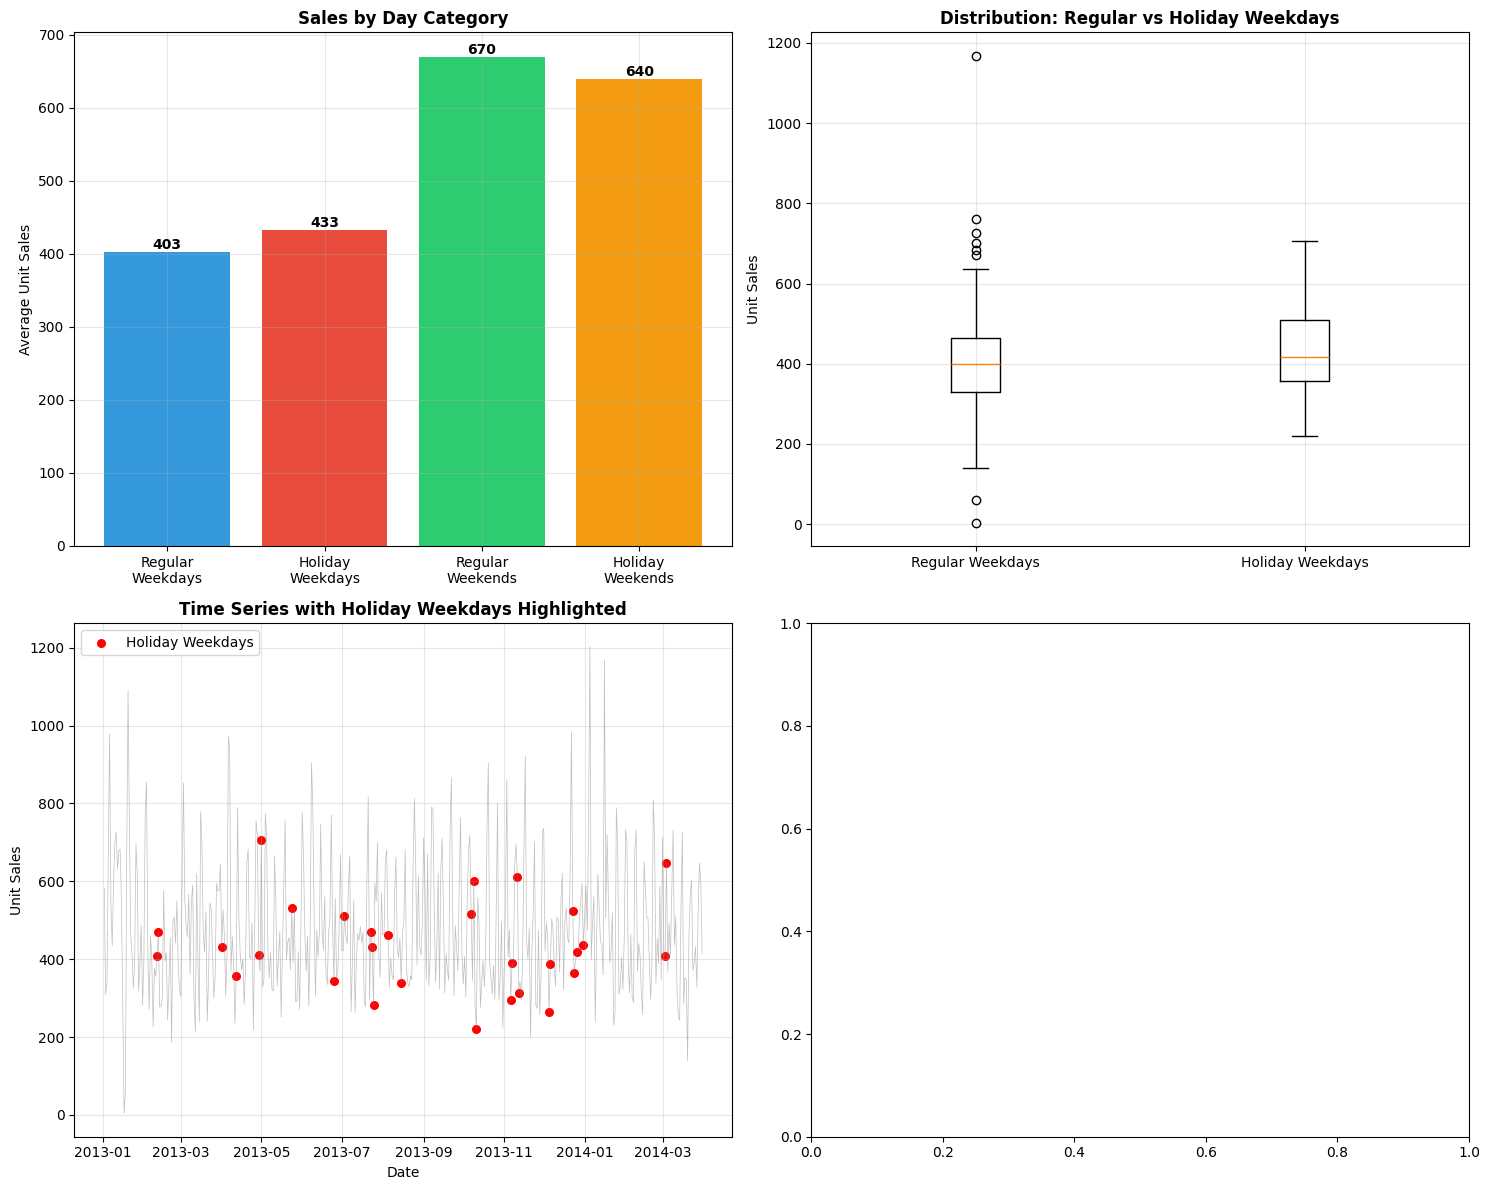


📋 EXECUTIVE SUMMARY

🎯 FOCUS: Holiday Weekdays vs Regular Weekdays

📊 KEY NUMBERS:
   • Holiday Weekday Average: 432.7 units (29 days)
   • Regular Weekday Average: 402.5 units (293 days)
   • Difference: +30.2 units (+7.5%)

🔬 STATISTICAL VERDICT:
   • p-value: 0.1896
   • ❌ Not Statistically Significant

💼 BUSINESS VERDICT:
   • Impact Magnitude: MODERATE
   • Recommendation: CONSIDER adjusting strategy

📈 INSIGHTS:
   • Holiday weekdays perform +7.5% better than regular weekdays
   • This translates to +30.2 additional units per holiday weekday
   • This is worth acting on!


💾 Results saved to: holiday_analysis_results.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================
# LOAD DATA
# ============================================
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'

# Load files
print("📂 LOADING DATA...")
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'))
timeseries = pd.read_csv(os.path.join(data_folder, 'timeseries.csv'))

# Convert dates
timeseries['date'] = pd.to_datetime(timeseries['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

print("=" * 80)
print("📊 HOLIDAYS vs NON-HOLIDAY WEEKDAYS ANALYSIS")
print("=" * 80)

# ============================================
# STEP 1: FILL MISSING UNIT SALES WITH MEAN
# ============================================
print("\n🔹 STEP 1: Cleaning sales data")

# Check missing values before
missing_before = timeseries['unit_sales'].isna().sum()
print(f"   Missing sales before: {missing_before} rows ({missing_before/len(timeseries)*100:.1f}%)")

# Fill with mean
sales_mean = timeseries['unit_sales'].mean()
timeseries['unit_sales'] = timeseries['unit_sales'].fillna(sales_mean)

# Check after
missing_after = timeseries['unit_sales'].isna().sum()
print(f"   Missing sales after: {missing_after} rows")
print(f"   ✅ Filled with mean: {sales_mean:.2f}")

# ============================================
# STEP 2: REMOVE HOLIDAYS WITHOUT DATES
# ============================================
print("\n🔹 STEP 2: Cleaning holidays table")

# Remove rows with missing dates
holidays_before = len(holidays)
holidays = holidays.dropna(subset=['date'])
holidays_after = len(holidays)

print(f"   Holidays before cleaning: {holidays_before}")
print(f"   Holidays after cleaning: {holidays_after}")
print(f"   ✅ Removed {holidays_before - holidays_after} rows with missing dates")

# ============================================
# STEP 3: FIND HOLIDAYS THAT MATCH DATE RANGE
# ============================================
print("\n🔹 STEP 3: Matching holidays with sales data")

# Get date range from timeseries
min_date = timeseries['date'].min()
max_date = timeseries['date'].max()
print(f"   Sales date range: {min_date.date()} to {max_date.date()}")

# Filter holidays within this range
holidays_in_range = holidays[
    (holidays['date'] >= min_date) &
    (holidays['date'] <= max_date)
].copy()

print(f"   Total holidays in data: {len(holidays)}")
print(f"   Holidays within sales range: {len(holidays_in_range)}")

if len(holidays_in_range) == 0:
    print("\n❌ No holidays found within your sales date range!")
    print("   Analysis cannot proceed.")
    exit()

# ============================================
# STEP 4: CREATE DAY TYPE CLASSIFICATIONS
# ============================================
print("\n🔹 STEP 4: Classifying days")

# Add day features
timeseries['day_of_week'] = timeseries['date'].dt.dayofweek  # 0=Monday, 6=Sunday
timeseries['day_name'] = timeseries['date'].dt.day_name()
timeseries['is_weekend'] = timeseries['day_of_week'].isin([5, 6])  # Saturday=5, Sunday=6

# Create holiday flag
holiday_dates_set = set(holidays_in_range['date'].dt.date)
timeseries['is_holiday'] = timeseries['date'].dt.date.isin(holiday_dates_set)

# Create combined category
def classify_day(row):
    if row['is_holiday']:
        if row['is_weekend']:
            return 'Holiday Weekend'
        else:
            return 'Holiday Weekday'
    else:
        if row['is_weekend']:
            return 'Regular Weekend'
        else:
            return 'Regular Weekday'

timeseries['day_category'] = timeseries.apply(classify_day, axis=1)

# Count each category
category_counts = timeseries['day_category'].value_counts()
print("\n   Day classification counts:")
for category in ['Regular Weekday', 'Regular Weekend', 'Holiday Weekday', 'Holiday Weekend']:
    count = category_counts.get(category, 0)
    print(f"   • {category}: {count} days")

# ============================================
# STEP 5: CALCULATE AVERAGES BY CATEGORY
# ============================================
print("\n" + "=" * 80)
print("📈 SALES BY DAY CATEGORY")
print("=" * 80)

# Calculate averages
category_avg = timeseries.groupby('day_category')['unit_sales'].agg(['mean', 'std', 'count']).round(2)
category_avg = category_avg.reindex(['Regular Weekday', 'Regular Weekend', 'Holiday Weekday', 'Holiday Weekend'])
print("\n", category_avg)

# ============================================
# STEP 6: HOLIDAY WEEKDAYS vs REGULAR WEEKDAYS
# ============================================
print("\n" + "=" * 80)
print("🎯 MAIN COMPARISON: HOLIDAY WEEKDAYS vs REGULAR WEEKDAYS")
print("=" * 80)

# Extract the two groups we care about
holiday_weekdays = timeseries[timeseries['day_category'] == 'Holiday Weekday']['unit_sales']
regular_weekdays = timeseries[timeseries['day_category'] == 'Regular Weekday']['unit_sales']

hw_mean = holiday_weekdays.mean()
rw_mean = regular_weekdays.mean()
hw_count = len(holiday_weekdays)
rw_count = len(regular_weekdays)
hw_std = holiday_weekdays.std()
rw_std = regular_weekdays.std()

print(f"\n📊 Average Sales:")
print(f"   • Holiday Weekdays:     {hw_mean:8.2f} units ({hw_count} days, std: {hw_std:.2f})")
print(f"   • Regular Weekdays:     {rw_mean:8.2f} units ({rw_count} days, std: {rw_std:.2f})")
print(f"   • Difference:           {hw_mean - rw_mean:8.2f} units")
print(f"   • Percent difference:   {((hw_mean - rw_mean) / rw_mean * 100):7.1f}%")

# ============================================
# STEP 7: STATISTICAL TEST
# ============================================
print("\n🔬 STATISTICAL SIGNIFICANCE TEST")

if len(holiday_weekdays) >= 2 and len(regular_weekdays) >= 2:
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(holiday_weekdays, regular_weekdays, equal_var=False)

    print(f"\n   Welch's t-test results:")
    print(f"   • t-statistic: {t_stat:.4f}")
    print(f"   • p-value: {p_value:.4f}")

    # Interpretation
    print(f"\n   📌 INTERPRETATION:")
    if p_value < 0.05:
        print(f"   ✅ The difference IS statistically significant (p < 0.05)")
        print(f"   → We are 95% confident this is a REAL effect")
    else:
        print(f"   ❌ The difference is NOT statistically significant (p > 0.05)")

        # Explain why
        if hw_count < 10:
            print(f"   → REASON: Only {hw_count} holiday weekdays in data")
            print(f"     (Need more data to prove significance)")
        elif rw_std > rw_mean * 0.3:
            print(f"   → REASON: High variability in weekday sales")
            print(f"     (Standard deviation is {rw_std:.1f}, mean is {rw_mean:.1f})")
        else:
            print(f"   → REASON: Effect size may be too small to detect")

        # Calculate power
        effect_size = abs(hw_mean - rw_mean) / rw_std
        print(f"   → Effect size (Cohen's d): {effect_size:.3f}")
        if effect_size < 0.2:
            print(f"     (Small effect - hard to detect)")
        elif effect_size < 0.5:
            print(f"     (Medium effect - more data would help)")
        else:
            print(f"     (Large effect - should be significant with more data)")
else:
    print("\n   ⚠️ Insufficient data for statistical test")

# ============================================
# STEP 8: PRACTICAL SIGNIFICANCE (BUSINESS IMPACT)
# ============================================
print("\n" + "=" * 80)
print("💼 PRACTICAL/BUSINESS SIGNIFICANCE")
print("=" * 80)

percent_diff = ((hw_mean - rw_mean) / rw_mean * 100) if rw_mean != 0 else 0
abs_diff = hw_mean - rw_mean

print(f"\n   • Absolute difference: {abs_diff:+.1f} units per holiday weekday")
print(f"   • Relative difference: {percent_diff:+.1f}%")

# Business impact thresholds
if abs(percent_diff) > 20:
    impact = "VERY LARGE"
    recommendation = "DEFINITELY adjust strategy"
elif abs(percent_diff) > 10:
    impact = "LARGE"
    recommendation = "STRONGLY CONSIDER adjusting strategy"
elif abs(percent_diff) > 5:
    impact = "MODERATE"
    recommendation = "CONSIDER adjusting strategy"
elif abs(percent_diff) > 2:
    impact = "SMALL"
    recommendation = "MONITOR, but may not need changes"
else:
    impact = "NEGLIGIBLE"
    recommendation = "IGNORE for now"

print(f"\n   • Business impact: {impact}")
print(f"   • Recommendation: {recommendation}")

# ============================================
# STEP 9: INDIVIDUAL HOLIDAY BREAKDOWN (WEEKDAYS ONLY)
# ============================================
if 'holiday_name' in holidays_in_range.columns:
    print("\n" + "=" * 80)
    print("📅 INDIVIDUAL HOLIDAY WEEKDAY IMPACT")
    print("=" * 80)

    # Merge to get holiday names
    timeseries_with_names = timeseries.merge(
        holidays_in_range[['date', 'holiday_name']],
        on='date',
        how='left'
    )

    # Filter for weekday holidays only
    weekday_holidays = timeseries_with_names[
        (timeseries_with_names['is_holiday']) &
        (~timeseries_with_names['is_weekend'])
    ].copy()

    if len(weekday_holidays) > 0:
        holiday_results = []

        for holiday_name in weekday_holidays['holiday_name'].unique():
            holiday_data = weekday_holidays[weekday_holidays['holiday_name'] == holiday_name]

            if len(holiday_data) > 0:
                h_avg = holiday_data['unit_sales'].mean()
                h_std = holiday_data['unit_sales'].std()
                h_count = len(holiday_data)
                h_pct = ((h_avg - rw_mean) / rw_mean * 100)

                holiday_results.append({
                    'Holiday': holiday_name[:30] + ('...' if len(holiday_name) > 30 else ''),
                    'Date': holiday_data['date'].iloc[0].strftime('%Y-%m-%d'),
                    'Avg Sales': f"{h_avg:.0f}",
                    'vs Weekday': f"{h_pct:+.1f}%",
                    'Days': h_count
                })

        # Display results
        holiday_df = pd.DataFrame(holiday_results)
        holiday_df = holiday_df.sort_values('vs Weekday', ascending=False)
        print("\n", holiday_df.to_string(index=False))
    else:
        print("\n   No weekday holidays found with names")

# ============================================
# STEP 10: VISUALIZATION
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Bar chart comparison
categories = ['Regular\nWeekdays', 'Holiday\nWeekdays', 'Regular\nWeekends', 'Holiday\nWeekends']
means = [
    regular_weekdays.mean(),
    holiday_weekdays.mean() if len(holiday_weekdays) > 0 else 0,
    timeseries[timeseries['day_category'] == 'Regular Weekend']['unit_sales'].mean(),
    timeseries[timeseries['day_category'] == 'Holiday Weekend']['unit_sales'].mean()
]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

bars = axes[0,0].bar(categories, means, color=colors)
axes[0,0].set_ylabel('Average Unit Sales')
axes[0,0].set_title('Sales by Day Category', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Box plot (Weekday comparison only)
if len(holiday_weekdays) > 0:
    box_data = [regular_weekdays, holiday_weekdays]
    axes[0,1].boxplot(box_data, tick_labels=['Regular Weekdays', 'Holiday Weekdays'])
    axes[0,1].set_ylabel('Unit Sales')
    axes[0,1].set_title('Distribution: Regular vs Holiday Weekdays', fontweight='bold')
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Time series with highlights
ax = axes[1,0]
ax.plot(timeseries['date'], timeseries['unit_sales'], alpha=0.5, linewidth=0.5, color='gray')

# Highlight holiday weekdays
holiday_weekday_dates = timeseries[timeseries['day_category'] == 'Holiday Weekday']['date']
holiday_weekday_values = timeseries[timeseries['day_category'] == 'Holiday Weekday']['unit_sales']
ax.scatter(holiday_weekday_dates, holiday_weekday_values, color='red', s=30, label='Holiday Weekdays')

ax.set_xlabel('Date')
ax.set_ylabel('Unit Sales')
ax.set_title('Time Series with Holiday Weekdays Highlighted', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Percentage difference by holiday (if available)
if 'holiday_results' in locals() and len(holiday_results) > 0:
    top_holidays = pd.DataFrame(holiday_results).head(8)
    pcts = [float(x.replace('%', '').replace('+', '')) for x in top_holidays['vs Weekday']]
    y_pos = range(len(top_holidays))

    bars = axes[1,1].barh(y_pos, pcts)
    axes[1,1].set_yticks(y_pos)
    axes[1,1].set_yticklabels(top_holidays['Holiday'])
    axes[1,1].set_xlabel('Percentage Difference vs Regular Weekdays (%)')
    axes[1,1].set_title('Top Holiday Weekdays by Impact', fontweight='bold')
    axes[1,1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[1,1].grid(True, alpha=0.3)

    # Color bars
    for bar, pct in zip(bars, pcts):
        bar.set_color('green' if pct > 0 else 'red')

plt.tight_layout()
plt.show()

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "=" * 80)
print("📋 EXECUTIVE SUMMARY")
print("=" * 80)

print(f"""
🎯 FOCUS: Holiday Weekdays vs Regular Weekdays

📊 KEY NUMBERS:
   • Holiday Weekday Average: {hw_mean:.1f} units ({hw_count} days)
   • Regular Weekday Average: {rw_mean:.1f} units ({rw_count} days)
   • Difference: {abs_diff:+.1f} units ({percent_diff:+.1f}%)

🔬 STATISTICAL VERDICT:
   • p-value: {p_value:.4f}
   • {'✅ Statistically Significant' if p_value < 0.05 else '❌ Not Statistically Significant'}

💼 BUSINESS VERDICT:
   • Impact Magnitude: {impact}
   • Recommendation: {recommendation}

📈 INSIGHTS:
   • Holiday weekdays perform {percent_diff:+.1f}% {'better' if percent_diff>0 else 'worse'} than regular weekdays
   • This translates to {abs_diff:+.1f} additional units per holiday weekday
   • {'This is worth acting on!' if abs(percent_diff) > 5 else 'Impact is minimal for now'}
""")

# Export results to CSV
results_df = pd.DataFrame({
    'Category': ['Regular Weekdays', 'Holiday Weekdays', 'Regular Weekends', 'Holiday Weekends'],
    'Avg_Sales': means,
    'Days': [
        len(regular_weekdays),
        len(holiday_weekdays),
        len(timeseries[timeseries['day_category'] == 'Regular Weekend']),
        len(timeseries[timeseries['day_category'] == 'Holiday Weekend'])
    ]
})
results_df.to_csv(os.path.join(data_folder, 'holiday_analysis_results.csv'), index=False)
print("\n💾 Results saved to: holiday_analysis_results.csv")

📂 LOADING DATA...
📊 HOLIDAY vs NON-HOLIDAY ANALYSIS - BY DAY OF WEEK

🔹 STEP 1: Cleaning sales data
   ✅ Filled 0 missing values with mean: 480.09

🔹 STEP 2: Cleaning holidays table
   ✅ Holidays after cleaning: 350

🔹 STEP 3: Matching holidays with sales data
   ✅ Holidays in date range: 54

🔹 STEP 4: Adding day of week features
   Total days: 452
   Holiday days: 47
   Non-holiday days: 405

📈 HOLIDAY vs NON-HOLIDAY SALES BY DAY OF WEEK

📊 SUMMARY TABLE:
------------------------------------------------------------------------------------------

🟢 Monday:
   Holiday:      471.00 units (8 days)
   Non-Holiday:   424.21 units (57 days)
   Difference:   +46.79 units ( +11.0%)
   Statistics: p=0.1386 - ❌ not significant
   Winner:     Holiday

🟢 Tuesday:
   Holiday:      435.29 units (7 days)
   Non-Holiday:   393.11 units (57 days)
   Difference:   +42.18 units ( +10.7%)
   Statistics: p=0.3674 - ❌ not significant
   Winner:     Holiday

🟢 Wednesday:
   Holiday:      508.40 units (5 days

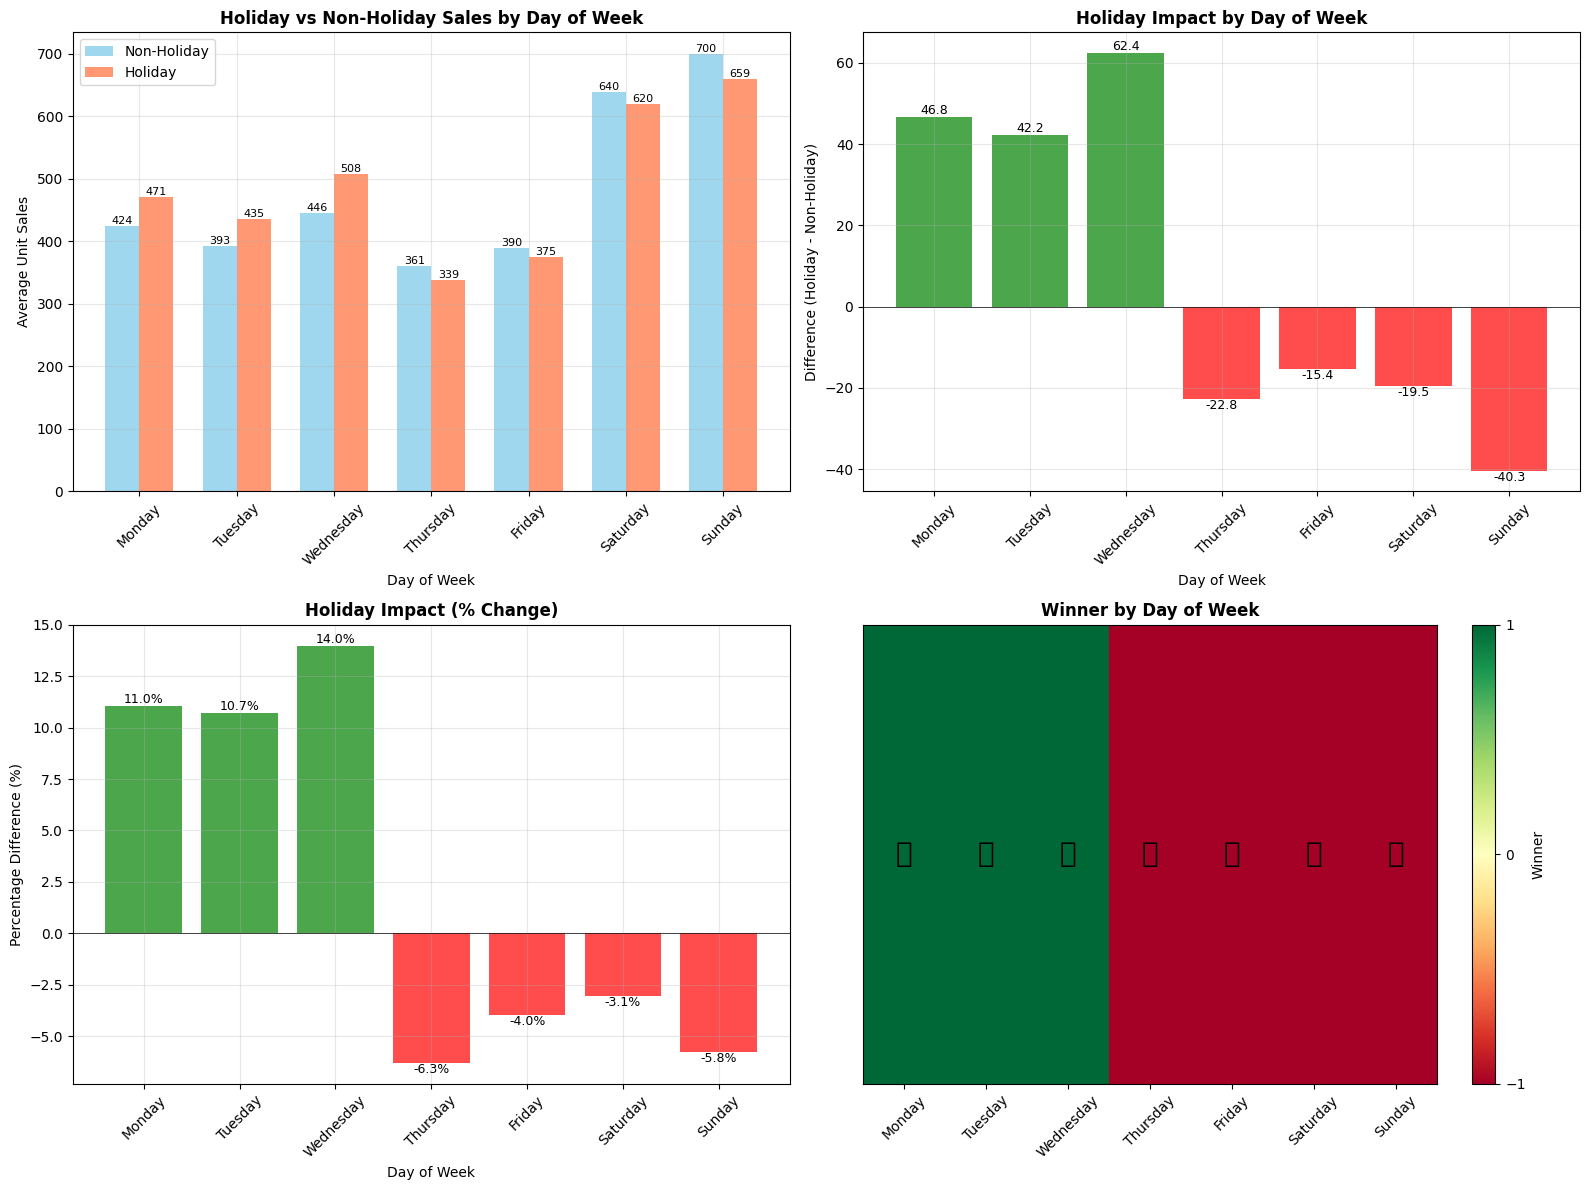


📋 EXECUTIVE SUMMARY - HOLIDAY vs NON-HOLIDAY BY DAY

📊 OVERALL AVERAGES:
   • Holiday days:      486.8 units
   • Non-holiday days:  479.2 units
   • Overall difference: +7.6 units (+1.6%)

🏆 DAY-BY-DAY WINNERS:

   🟢 Monday: Holiday wins (❌ p=0.139)
   🟢 Tuesday: Holiday wins (❌ p=0.367)
   🟢 Wednesday: Holiday wins (❌ p=0.428)
   🔴 Thursday: Non-Holiday wins (❌ p=0.545)
   🔴 Friday: Non-Holiday wins (❌ p=0.827)
   🔴 Saturday: Non-Holiday wins (❌ p=0.357)
   🔴 Sunday: Non-Holiday wins (❌ p=0.561)

📈 KEY INSIGHTS:
   • Best day for holidays: Wednesday (+14.0% vs normal)
   • Worst day for holidays: Thursday (-6.3% vs normal)
   • Holidays work best on: Monday, Tuesday, Wednesday
   • Regular days outperform on: Thursday, Friday, Saturday, Sunday

💼 BUSINESS RECOMMENDATION:

   ❌ Holidays generally DECREASE sales (lose on 4/7 days)
   → Be cautious with holiday promotions, especially on: Thursday, Friday, Saturday, Sunday

💾 Detailed results saved to: holiday_by_day_results.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================
# LOAD DATA
# ============================================
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'

print("📂 LOADING DATA...")
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'))
timeseries = pd.read_csv(os.path.join(data_folder, 'timeseries.csv'))

# Convert dates
timeseries['date'] = pd.to_datetime(timeseries['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

print("=" * 90)
print("📊 HOLIDAY vs NON-HOLIDAY ANALYSIS - BY DAY OF WEEK")
print("=" * 90)

# ============================================
# STEP 1: FILL MISSING UNIT SALES WITH MEAN
# ============================================
print("\n🔹 STEP 1: Cleaning sales data")

missing_before = timeseries['unit_sales'].isna().sum()
sales_mean = timeseries['unit_sales'].mean()
timeseries['unit_sales'] = timeseries['unit_sales'].fillna(sales_mean)
print(f"   ✅ Filled {missing_before} missing values with mean: {sales_mean:.2f}")

# ============================================
# STEP 2: CLEAN HOLIDAYS TABLE
# ============================================
print("\n🔹 STEP 2: Cleaning holidays table")

holidays = holidays.dropna(subset=['date'])
print(f"   ✅ Holidays after cleaning: {len(holidays)}")

# ============================================
# STEP 3: FILTER HOLIDAYS TO DATE RANGE
# ============================================
print("\n🔹 STEP 3: Matching holidays with sales data")

min_date = timeseries['date'].min()
max_date = timeseries['date'].max()
holidays_in_range = holidays[
    (holidays['date'] >= min_date) &
    (holidays['date'] <= max_date)
].copy()

print(f"   ✅ Holidays in date range: {len(holidays_in_range)}")

if len(holidays_in_range) == 0:
    print("\n❌ No holidays found within your sales date range!")
    exit()

# ============================================
# STEP 4: CREATE DAY OF WEEK FEATURES
# ============================================
print("\n🔹 STEP 4: Adding day of week features")

# Day of week (0=Monday, 6=Sunday)
timeseries['day_of_week'] = timeseries['date'].dt.dayofweek
timeseries['day_name'] = timeseries['date'].dt.day_name()

# Create holiday flag
holiday_dates_set = set(holidays_in_range['date'].dt.date)
timeseries['is_holiday'] = timeseries['date'].dt.date.isin(holiday_dates_set)

# Create flag for analysis
timeseries['day_type'] = np.where(timeseries['is_holiday'], 'Holiday', 'Non-Holiday')

print(f"   Total days: {len(timeseries)}")
print(f"   Holiday days: {timeseries['is_holiday'].sum()}")
print(f"   Non-holiday days: {(~timeseries['is_holiday']).sum()}")

# ============================================
# STEP 5: ANALYSIS BY DAY OF WEEK
# ============================================
print("\n" + "=" * 90)
print("📈 HOLIDAY vs NON-HOLIDAY SALES BY DAY OF WEEK")
print("=" * 90)

# Order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
           4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

# Create results dataframe
results = []

for day_num, day_name in day_map.items():
    # Filter for this day of week
    day_data = timeseries[timeseries['day_of_week'] == day_num]

    # Split into holiday and non-holiday
    holiday_data = day_data[day_data['is_holiday']]['unit_sales']
    non_holiday_data = day_data[~day_data['is_holiday']]['unit_sales']

    # Calculate statistics
    h_mean = holiday_data.mean() if len(holiday_data) > 0 else np.nan
    h_count = len(holiday_data)
    h_std = holiday_data.std() if len(holiday_data) > 1 else np.nan

    n_mean = non_holiday_data.mean() if len(non_holiday_data) > 0 else np.nan
    n_count = len(non_holiday_data)
    n_std = non_holiday_data.std() if len(non_holiday_data) > 1 else np.nan

    # Calculate difference
    diff = h_mean - n_mean if not np.isnan(h_mean) and not np.isnan(n_mean) else np.nan
    pct_diff = (diff / n_mean * 100) if not np.isnan(diff) and n_mean != 0 else np.nan

    # Statistical test
    p_value = np.nan
    if len(holiday_data) >= 2 and len(non_holiday_data) >= 2:
        t_stat, p_value = stats.ttest_ind(holiday_data, non_holiday_data, equal_var=False)

    # Determine which is better
    if not np.isnan(diff):
        if diff > 0:
            better = "HOLIDAY"
            winner = "Holiday"
        elif diff < 0:
            better = "NON-HOLIDAY"
            winner = "Non-Holiday"
        else:
            better = "EQUAL"
            winner = "Equal"
    else:
        better = "INSUFFICIENT DATA"
        winner = "N/A"

    results.append({
        'Day': day_name,
        'Holiday Avg': h_mean,
        'Holiday Count': h_count,
        'Non-Holiday Avg': n_mean,
        'Non-Holiday Count': n_count,
        'Difference': diff,
        'Percent Diff': pct_diff,
        'Better': better,
        'Winner': winner,
        'P-Value': p_value
    })

# Create DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Day').reindex(day_order).reset_index()

# Display formatted results
print("\n📊 SUMMARY TABLE:")
print("-" * 90)
for idx, row in results_df.iterrows():
    winner_color = "🟢" if row['Winner'] == "Holiday" else "🔴" if row['Winner'] == "Non-Holiday" else "⚪"

    print(f"\n{winner_color} {row['Day']}:")
    print(f"   Holiday:    {row['Holiday Avg']:8.2f} units ({row['Holiday Count']} days)")
    print(f"   Non-Holiday: {row['Non-Holiday Avg']:8.2f} units ({row['Non-Holiday Count']} days)")

    if not np.isnan(row['Difference']):
        print(f"   Difference: {row['Difference']:+8.2f} units ({row['Percent Diff']:+6.1f}%)")

        if row['P-Value'] < 0.05:
            sig = "✅ SIGNIFICANT"
        else:
            sig = "❌ not significant"
        print(f"   Statistics: p={row['P-Value']:.4f} - {sig}")

        print(f"   Winner:     {row['Winner']}")
    else:
        print(f"   ⚠️ Insufficient data for comparison")

# ============================================
# STEP 6: WHICH DAY IS BEST FOR HOLIDAYS?
# ============================================
print("\n" + "=" * 90)
print("🏆 WHICH DAY IS BEST FOR HOLIDAYS?")
print("=" * 90)

# Filter to days with valid data
valid_results = results_df[results_df['Holiday Avg'].notna()].copy()

if len(valid_results) > 0:
    # Best holiday day (highest sales)
    best_holiday_day = valid_results.loc[valid_results['Holiday Avg'].idxmax()]

    # Best non-holiday day
    best_normal_day = valid_results.loc[valid_results['Non-Holiday Avg'].idxmax()]

    # Biggest holiday impact
    valid_results['Abs Diff'] = valid_results['Difference'].abs()
    biggest_impact = valid_results.loc[valid_results['Abs Diff'].idxmax()]

    print(f"\n📅 BEST DAY FOR HOLIDAY SALES:")
    print(f"   🏆 {best_holiday_day['Day']} - {best_holiday_day['Holiday Avg']:.2f} units")
    print(f"      (vs normal {best_holiday_day['Day']}: {best_holiday_day['Non-Holiday Avg']:.2f})")
    print(f"      Difference: {best_holiday_day['Difference']:+.2f} ({best_holiday_day['Percent Diff']:+.1f}%)")

    print(f"\n📅 BEST DAY FOR REGULAR SALES:")
    print(f"   📊 {best_normal_day['Day']} - {best_normal_day['Non-Holiday Avg']:.2f} units")

    print(f"\n📈 BIGGEST HOLIDAY IMPACT:")
    if biggest_impact['Difference'] > 0:
        print(f"   ⬆️ {biggest_impact['Day']} - +{biggest_impact['Difference']:.2f} units (+{biggest_impact['Percent Diff']:.1f}%)")
    else:
        print(f"   ⬇️ {biggest_impact['Day']} - {biggest_impact['Difference']:.2f} units ({biggest_impact['Percent Diff']:.1f}%)")

    # Count winners
    holiday_wins = len(valid_results[valid_results['Winner'] == 'Holiday'])
    non_holiday_wins = len(valid_results[valid_results['Winner'] == 'Non-Holiday'])
    ties = len(valid_results[valid_results['Winner'] == 'Equal'])

    print(f"\n📊 OVERALL:")
    print(f"   • Holiday performs better on {holiday_wins} days")
    print(f"   • Non-Holiday performs better on {non_holiday_wins} days")
    print(f"   • Equal on {ties} days")
else:
    print("\n❌ No valid data for comparison")

# ============================================
# STEP 7: STATISTICAL SUMMARY
# ============================================
print("\n" + "=" * 90)
print("📊 DETAILED STATISTICAL SUMMARY")
print("=" * 90)

# Create formatted table
display_df = valid_results[['Day', 'Holiday Avg', 'Non-Holiday Avg', 'Difference', 'Percent Diff', 'P-Value', 'Winner']].copy()
display_df['Holiday Avg'] = display_df['Holiday Avg'].round(1)
display_df['Non-Holiday Avg'] = display_df['Non-Holiday Avg'].round(1)
display_df['Difference'] = display_df['Difference'].round(1)
display_df['Percent Diff'] = display_df['Percent Diff'].round(1).astype(str) + '%'
display_df['P-Value'] = display_df['P-Value'].round(4)
display_df['Winner'] = display_df['Winner'].apply(lambda x: f"🟢 {x}" if x == 'Holiday' else f"🔴 {x}" if x == 'Non-Holiday' else f"⚪ {x}")

print("\n", display_df.to_string(index=False))

# ============================================
# STEP 8: VISUALIZATION
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Grouped bar chart
x = np.arange(len(day_order))
width = 0.35

holiday_values = [results_df[results_df['Day'] == day]['Holiday Avg'].values[0] if len(results_df[results_df['Day'] == day]['Holiday Avg'].values) > 0 else 0 for day in day_order]
non_holiday_values = [results_df[results_df['Day'] == day]['Non-Holiday Avg'].values[0] if len(results_df[results_df['Day'] == day]['Non-Holiday Avg'].values) > 0 else 0 for day in day_order]

bars1 = axes[0,0].bar(x - width/2, non_holiday_values, width, label='Non-Holiday', color='skyblue', alpha=0.8)
bars2 = axes[0,0].bar(x + width/2, holiday_values, width, label='Holiday', color='coral', alpha=0.8)

axes[0,0].set_xlabel('Day of Week')
axes[0,0].set_ylabel('Average Unit Sales')
axes[0,0].set_title('Holiday vs Non-Holiday Sales by Day of Week', fontweight='bold')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(day_order, rotation=45)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.0f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Difference by day
diff_values = [results_df[results_df['Day'] == day]['Difference'].values[0] if len(results_df[results_df['Day'] == day]['Difference'].values) > 0 else 0 for day in day_order]
colors = ['green' if d > 0 else 'red' if d < 0 else 'gray' for d in diff_values]

bars = axes[0,1].bar(day_order, diff_values, color=colors, alpha=0.7)
axes[0,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0,1].set_xlabel('Day of Week')
axes[0,1].set_ylabel('Difference (Holiday - Non-Holiday)')
axes[0,1].set_title('Holiday Impact by Day of Week', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# Add value labels
for bar, diff in zip(bars, diff_values):
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                  f'{diff:.1f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

# Plot 3: Percentage difference
pct_values = [results_df[results_df['Day'] == day]['Percent Diff'].values[0] if len(results_df[results_df['Day'] == day]['Percent Diff'].values) > 0 else 0 for day in day_order]
colors = ['green' if p > 0 else 'red' if p < 0 else 'gray' for p in pct_values]

bars = axes[1,0].bar(day_order, pct_values, color=colors, alpha=0.7)
axes[1,0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1,0].set_xlabel('Day of Week')
axes[1,0].set_ylabel('Percentage Difference (%)')
axes[1,0].set_title('Holiday Impact (% Change)', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# Add value labels
for bar, pct in zip(bars, pct_values):
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                  f'{pct:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

# Plot 4: Heatmap of winners
winner_matrix = np.array([[1 if w == 'Holiday' else -1 if w == 'Non-Holiday' else 0 for w in valid_results['Winner']]])
im = axes[1,1].imshow(winner_matrix, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
axes[1,1].set_yticks([])
axes[1,1].set_xticks(range(len(valid_results)))
axes[1,1].set_xticklabels(valid_results['Day'], rotation=45)
axes[1,1].set_title('Winner by Day of Week', fontweight='bold')

# Add text annotations
for i, winner in enumerate(valid_results['Winner']):
    color = 'white'
    text = '🏆' if winner == 'Holiday' else '📉' if winner == 'Non-Holiday' else '⚖️'
    axes[1,1].text(i, 0, text, ha='center', va='center', fontsize=20)

plt.colorbar(im, ax=axes[1,1], ticks=[-1, 0, 1], label='Winner')
plt.tight_layout()
plt.show()

# ============================================
# FINAL CONCLUSION
# ============================================
print("\n" + "=" * 90)
print("📋 EXECUTIVE SUMMARY - HOLIDAY vs NON-HOLIDAY BY DAY")
print("=" * 90)

# Find overall winner
avg_holiday = valid_results['Holiday Avg'].mean()
avg_non_holiday = valid_results['Non-Holiday Avg'].mean()
overall_diff = avg_holiday - avg_non_holiday
overall_pct = (overall_diff / avg_non_holiday * 100) if avg_non_holiday != 0 else 0

print(f"""
📊 OVERALL AVERAGES:
   • Holiday days:      {avg_holiday:.1f} units
   • Non-holiday days:  {avg_non_holiday:.1f} units
   • Overall difference: {overall_diff:+.1f} units ({overall_pct:+.1f}%)

🏆 DAY-BY-DAY WINNERS:
""")

for idx, row in valid_results.iterrows():
    emoji = "🟢" if row['Winner'] == 'Holiday' else "🔴" if row['Winner'] == 'Non-Holiday' else "⚪"
    sig = "✅" if row['P-Value'] < 0.05 else "❌"
    print(f"   {emoji} {row['Day']}: {row['Winner']} wins ({sig} p={row['P-Value']:.3f})")

# Best and worst
best_day = valid_results.loc[valid_results['Percent Diff'].idxmax()]
worst_day = valid_results.loc[valid_results['Percent Diff'].idxmin()]

print(f"""
📈 KEY INSIGHTS:
   • Best day for holidays: {best_day['Day']} (+{best_day['Percent Diff']:.1f}% vs normal)
   • Worst day for holidays: {worst_day['Day']} ({worst_day['Percent Diff']:.1f}% vs normal)
   • Holidays work best on: {', '.join(valid_results[valid_results['Winner'] == 'Holiday']['Day'].tolist())}
   • Regular days outperform on: {', '.join(valid_results[valid_results['Winner'] == 'Non-Holiday']['Day'].tolist())}

💼 BUSINESS RECOMMENDATION:
""")

if holiday_wins > non_holiday_wins:
    print(f"   ✅ Holidays generally INCREASE sales (win on {holiday_wins}/{len(valid_results)} days)")
    print(f"   → Focus holiday promotions on: {', '.join(valid_results[valid_results['Winner'] == 'Holiday']['Day'].tolist())}")
else:
    print(f"   ❌ Holidays generally DECREASE sales (lose on {non_holiday_wins}/{len(valid_results)} days)")
    print(f"   → Be cautious with holiday promotions, especially on: {', '.join(valid_results[valid_results['Winner'] == 'Non-Holiday']['Day'].tolist())}")

# Save results
valid_results.to_csv(os.path.join(data_folder, 'holiday_by_day_results.csv'), index=False)
print(f"\n💾 Detailed results saved to: holiday_by_day_results.csv")